In [2]:
import igl
import scipy as sp
import numpy as np
import os
from pathlib import Path

repo_root = Path(os.getcwd()).parent

fs = [repo_root / "data" / "closed_myles" / "filigree100K_output", 
      repo_root / "output" / "Lp_2" / "filigree100K_output"]
ms = ["filigree100K_refined_with_uv.obj", "filigree100K_refined_with_uv_out_CG_1e-3.obj"]

In [146]:
import sys
from pathlib import Path
repo_root = Path(os.getcwd()).parent
module_dir = str(repo_root / "py")
sys.path.append(module_dir)
    
import symdir

def load_symmetric_dirichlet_energy(mesh_path):
    
    fname = os.path.basename(str(mesh_path))
    dot_index = fname.rfind(".")
    m = fname[:dot_index]

    # Load uv information
    v3d, uv, _, f, fuv, _ = igl.readOBJ(str(mesh_path))

    # Compute chosen vertex energy
    mesh_cutter = symdir.MeshCutter(v3d,uv, f, fuv)
    v_cut, _ = mesh_cutter.cut_mesh()
    X = symdir.symmetric_dirichlet_energy(v_cut, fuv, uv, 1) - 4.
    return X

X_0 = load_symmetric_dirichlet_energy(fs[0]/ms[0])


[2026-01-06 21:15:02.060] [info] 14952 boundary faces


In [147]:
print(max(X_0), max(X_1))

13644238379.02819 43.77207219796092


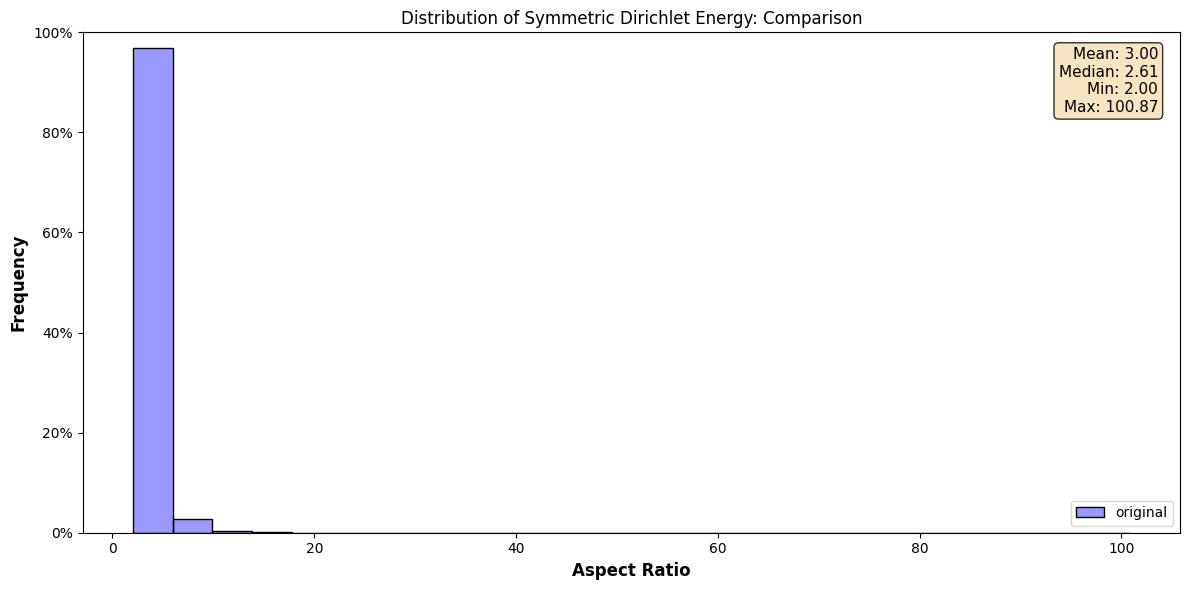

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

def compute_aspect_ratio(v3d, f):
    """Compute aspect ratio statistics for the mesh."""
    def triangle_aspect_ratio(v0, v1, v2):
        a = np.linalg.norm(v1 - v0)
        b = np.linalg.norm(v2 - v1)
        c = np.linalg.norm(v0 - v2)
        s = (a + b + c) / 2.0
        area = max(s * (s - a) * (s - b) * (s - c), 1e-10)**0.5
        inradius = area / s
        circumradius = (a * b * c) / (4.0 * area)
        return circumradius / inradius

    aspect_ratios = []
    for face in f:
        v0, v1, v2 = v3d[face]
        ar = triangle_aspect_ratio(v0, v1, v2)
        aspect_ratios.append(ar)

    aspect_ratios = np.array(aspect_ratios)
    return aspect_ratios

# Load uv information
v3d, uv, _, f, fuv, _ = igl.readOBJ(m0)

aspect_ratios = compute_aspect_ratio(v3d, f)

# Create histogram
fig, ax = plt.subplots(figsize=(12, 6))
bins = 25
bingrange = []

sns.histplot(aspect_ratios, bins=bins, stat='percent', ax=ax, alpha=0.4, label='original', color='blue')

ax.set_xlabel('Aspect Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.set_ylim(0, 100)

# Add statistics
mean_ar = np.mean(aspect_ratios)
median_ar = np.median(aspect_ratios)
max_ar = np.max(aspect_ratios)
min_ar = np.min(aspect_ratios)

stats_text = f"Mean: {mean_ar:.2f}\nMedian: {median_ar:.2f}\nMin: {min_ar:.2f}\nMax: {max_ar:.2f}"
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.title('Distribution of Symmetric Dirichlet Energy: Comparison')
plt.legend()
plt.tight_layout()
plt.show()


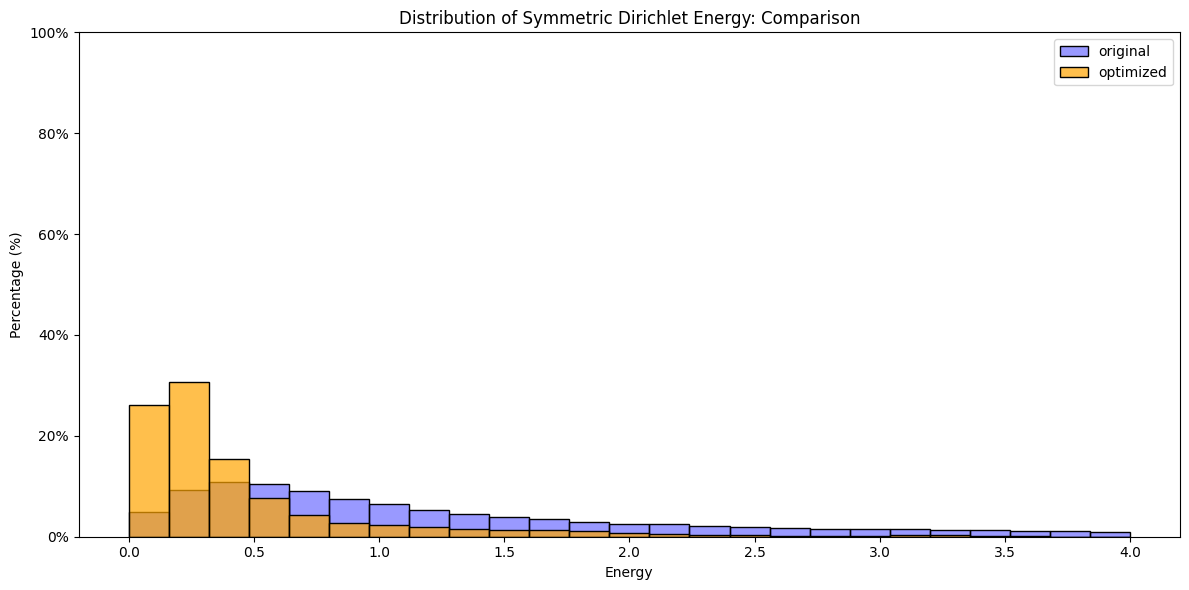

In [132]:

# Get bin range (or None if no range values provided)
binrange = (0, 4)

# Set percentage or absolute scale for y axis
fig, ax = plt.subplots(figsize=(12, 6))
bins = 25

# Plot X_0 with lower opacity (more transparent)
sns.histplot(X_0, bins=bins, stat='percent', binrange=binrange, ax=ax, alpha=0.4, label='original', color='blue')

# Plot X_1 with higher opacity (less transparent)
sns.histplot(X_1, bins=bins, stat='percent', binrange=binrange, ax=ax, alpha=0.7, label='optimized', color='orange')

ax.set_xlabel('Energy')
ax.set_ylabel('Percentage (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Set y-axis limit (adjust 100 to your preferred max value)
ax.set_ylim(0, 100)

plt.title('Distribution of Symmetric Dirichlet Energy: Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [148]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Load the JSON files for all tests
data = []
names = ["Lp2", "Lp_shifted_2.0"]
for f in fs[1:]:
    json_path = f / "pulley100K_refined_with_uv_CG_1e-3.json"
    print(json_path)
    with open(json_path) as f:
        data.append(json.load(f))

# Get total number of faces from the mesh
v3d, uv, _, f, fuv, _ = igl.readOBJ(str(fs[0]/ms[0]))
total_faces = f.shape[0]

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Define colors for each test
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

for idx, d in enumerate(data):
    # Extract logs
    hessian_df = pd.DataFrame(d['hessian_log'])
    opt_df = pd.DataFrame(d['opt_log'])

    # ===== LEFT PLOT: Triangle Count Distribution =====
    time = opt_df['elapsed_time'].values
    counts = [tri_counts[0] for tri_counts in hessian_df['num_triangles']]
    
    # Convert to percentage
    percentages = [100 * count / total_faces for count in counts]
    
    # Create smooth spline curve
    spl = make_interp_spline(time, percentages, k=3)
    time_smooth = np.linspace(time.min(), time.max(), 300)
    percentages_smooth = spl(time_smooth)

    # Plot smooth curve with transparency and fill
    ax1.plot(time_smooth, percentages_smooth, color=colors[idx], linewidth=3.5, label=names[idx], alpha=0.8)

    # ===== RIGHT PLOT: Energy Convergence =====
    E_worst = opt_df['E_worst'].values
    
    # Create smooth spline curve for energy
    spl_energy = make_interp_spline(time, E_worst, k=3)
    time_smooth = np.linspace(time.min(), time.max(), 300)
    E_worst_smooth = spl_energy(time_smooth)
    
    # Plot smooth curve
    ax2.semilogy(time_smooth, E_worst_smooth, color=colors[idx], linewidth=3.5, label=names[idx], alpha=0.8)

# ===== LEFT PLOT SETTINGS =====
ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage of Faces (%)', fontsize=12, fontweight='bold')
ax1.set_title(f'Triangle Count Distribution (E ≤ 1.0)\n(Total Faces: {total_faces:,})', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='lower right', framealpha=0.95)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax1.set_ylim(0, 100)

# ===== RIGHT PLOT SETTINGS =====
ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax2.set_ylabel('E_worst (log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Energy Convergence', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', which='both')
ax2.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

/Users/aa13586/Desktop/symmetric-dirichlet/output/Lp_2/filigree100K_output/pulley100K_refined_with_uv_CG_1e-3.json


FileNotFoundError: [Errno 2] No such file or directory: '/Users/aa13586/Desktop/symmetric-dirichlet/output/Lp_2/filigree100K_output/pulley100K_refined_with_uv_CG_1e-3.json'

/Users/aa13586/Desktop/symmetric-dirichlet/output/filigree100K_output/filigree100K_refined_with_uv_CG_1e-3.json
/Users/aa13586/Desktop/symmetric-dirichlet/output/filigree100K_output_32/filigree100K_refined_with_uv_CG_1e-3.json


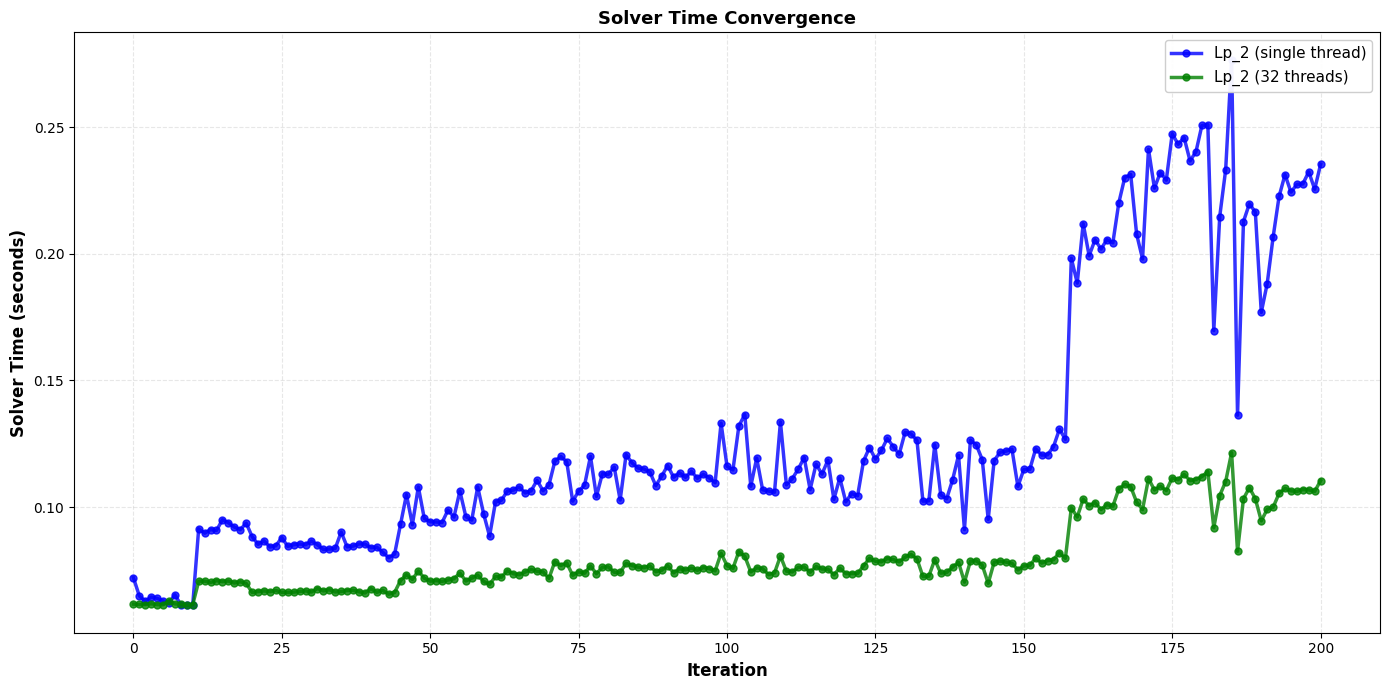

In [154]:
# Load the JSON files
data = []
fs = [repo_root / "output" / "filigree100K_output",
      repo_root / "output" / "filigree100K_output_32"]
names = ["Lp_2 (single thread)", "Lp_2 (32 threads)"]

for f in fs:
    json_path = f / "filigree100K_refined_with_uv_CG_1e-3.json"
    print(json_path)
    with open(json_path) as file:
        data.append(json.load(file))

# Create figure with single subplot
fig, ax1 = plt.subplots(1, figsize=(14, 7))

# Define colors for each test
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
times = []
for idx, d in enumerate(data):
    # Extract logs
    hessian_df = pd.DataFrame(d['hessian_log'])
    
    time_solver = hessian_df['time_solver'].values
    iterations = hessian_df['iteration'].values
    times.append(sum(time_solver))
    # Plot broken line (no spline interpolation)
    ax1.plot(iterations, time_solver, color=colors[idx], 
             linewidth=2.5, label=names[idx], alpha=0.8, marker='o', markersize=5)

# ===== PLOT SETTINGS =====
ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax1.set_ylabel('Solver Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Solver Time Convergence', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

In [9]:
import json
import pandas as pd
from pathlib import Path

# Define your output directories
output_dirs = [repo_root / "output" / "filigree100K"]

# Collect data
results = []

for output_dir in output_dirs:
    # Find all JSON files in the directory
    json_files = list(output_dir.glob("*.json"))
    
    for json_file in json_files:
        with open(json_file) as f:
            data = json.load(f)
        
        # Extract solver info and compute total time
        hessian_df = pd.DataFrame(data['hessian_log'])
        total_time = hessian_df['time_solver'].sum()
        
        # Get solver name and threads from JSON or filename
        solver_name = data.get('solver_type', 'Unknown')
        num_threads = data.get('num_threads', 'Unknown')
        
        results.append({
            'Solver': solver_name,
            'Threads': num_threads,
            'Solver Time (s)': f"{total_time:.3f}",
            'Total Time (s)': f"{data.get('total_time', 0):.3f}"
        })

# Create DataFrame
results_df = pd.DataFrame(results)

# Define solver order
solver_order = {'CG': 0, 'Parallel_CG': 1}
results_df['solver_sort_key'] = results_df['Solver'].map(solver_order).fillna(2)

# Sort by solver type first, then by number of threads (convert to int for proper sorting)
results_df['threads_sort_key'] = pd.to_numeric(results_df['Threads'], errors='coerce').fillna(0)
results_df = results_df.sort_values(['solver_sort_key', 'threads_sort_key']).drop(['solver_sort_key', 'threads_sort_key'], axis=1)
results_df = results_df.reset_index(drop=True)

# Display
print(results_df.to_string(index=False))

# Optional: Save to CSV
results_df.to_csv(repo_root / "solver_comparison.csv", index=False)

     Solver  Threads Solver Time (s) Total Time (s)
         CG        1          15.897         84.000
         CG        2          11.079         79.000
         CG        4           8.350         78.000
         CG        8           6.694         76.000
         CG       64           7.869         75.000
Parallel_CG        1         146.990        180.000
Parallel_CG        2         136.023        183.000
Parallel_CG        4         102.089        155.000
Parallel_CG        8          80.552        135.000
Parallel_CG       64         157.983        184.000
